# Comparing three models


## I. Imports and Global Settings

This cell loads the core libraries used throughout the notebook, including data processing tools, text vectorization, ranking models, evaluation metrics, and cross-validation utilities.

It also defines:
- `RANDOM_STATE` for reproducibility
- `STOPWORDS` for basic Vietnamese query normalization
- the original rating-related column names from the dataset
- `FEATURE_COLUMNS`, the final feature set used for modeling
- `FEATURE_LABELS`, human-readable descriptions for analysis and visualization


In [19]:
from __future__ import annotations

import re
import time
import unicodedata
from collections import defaultdict
from pathlib import Path
from typing import Any, Callable

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import Ridge
from sklearn.metrics import ndcg_score
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import GroupKFold, ParameterGrid
from sklearn.pipeline import Pipeline
from xgboost import XGBRanker

RANDOM_STATE = 42

STOPWORDS = {
    "toi", "muon", "hay", "cho", "biet", "tim", "kiem", "giup", "mot", "1",
    "nhung", "cac", "quan", "nha", "hang", "an", "o", "va", "co", "nao",
    "de", "di", "vao", "ban", "duoc", "goi", "y", "liet", "ke", "cua",
    "phu", "hop", "moi",
}

POSITION_COL = "Vị trí"
PRICE_VALUE_COL = "Giá cả"
QUALITY_COL = "Chất lượng"
SERVICE_COL = "Phục vụ"
SPACE_COL = "Không gian"
DELIVERY_COL = "Giao tận nơi"
BOOKING_COL = "Đặt bàn"
RATING_COLUMNS = [POSITION_COL, PRICE_VALUE_COL, QUALITY_COL, SERVICE_COL, SPACE_COL]

FEATURE_COLUMNS = [
    "text_match",
    "location_match",
    "price_fit",
    "rating_mean",
    "popularity_score",
    "service_match",
]

FEATURE_LABELS = {
    "text_match": "Match between the query and the restaurant description",
    "location_match": "Location / district match",
    "price_fit": "Price suitability",
    "rating_mean": "Average rating score",
    "popularity_score": "Overall popularity score",
    "service_match": "Service match (delivery / table booking)",
}


## II. Feature selection

### II.1. Load and Merge the Data

This section performs three main tasks:
- reads the relevance label table for each `(query, restaurant)` pair
- loads the restaurant metadata table
- normalizes `restaurant_id` so the two tables can be merged safely

It also includes a few helper functions:
- `normalize_text(...)` standardizes Vietnamese text by removing accents, lowercasing, and cleaning special characters
- `normalize_restaurant_id(...)` converts restaurant IDs into a consistent string format
- `tokenize(...)` splits normalized text into tokens while removing stopwords
- `canonical_location(...)` reduces location names to a simpler canonical form for easier matching

After this step, each row represents a `(query, restaurant)` pair with both label information and restaurant metadata, ready for feature engineering.


In [20]:
def normalize_text(text: Any) -> str:
    if text is None or (isinstance(text, float) and pd.isna(text)):
        return ""
    text = str(text).replace("Đ", "D").replace("đ", "d")
    text = unicodedata.normalize("NFKD", text)
    text = "".join(ch for ch in text if not unicodedata.combining(ch))
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s-]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def normalize_restaurant_id(value: Any) -> str:
    if pd.isna(value):
        return ""
    text = str(value).strip()
    if not text:
        return ""
    try:
        return str(int(float(text)))
    except Exception:
        return text

def tokenize(text: Any) -> list[str]:
    return [tok for tok in normalize_text(text).split() if tok and tok not in STOPWORDS]

def canonical_location(text: Any) -> str:
    location = normalize_text(text)
    location = re.sub(r"\b(thanh pho|tp|quan|q|huyen|h|thi xa|tx)\b", " ", location)
    return re.sub(r"\s+", " ", location).strip()

def load_merged_restaurant_ranking(
    labels_path: str | Path = Path("..") / "dataset" / "restaurant_dataset.csv",
    restaurants_path: str | Path = Path("..") / "dataset" / "foody_combined_data_final.csv",
) -> pd.DataFrame:
    labels_df = pd.read_csv(labels_path).rename(
        columns={"district": "label_district", "cuisines": "label_cuisines", "source": "retrieval_source"}
    )
    restaurants_df = pd.read_csv(restaurants_path)

    labels_df["restaurant_id"] = labels_df["restaurant_id"].map(normalize_restaurant_id)
    restaurants_df["restaurant_id"] = restaurants_df["RestaurantID"].map(normalize_restaurant_id)

    merged_df = labels_df.merge(restaurants_df, on="restaurant_id", how="left", validate="many_to_one")
    return merged_df

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_columns", 200)

PROJECT_ROOT = Path.cwd() if (Path.cwd() / "dataset").exists() else Path.cwd().parent
LABELS_PATH = PROJECT_ROOT / "dataset" / "restaurant_dataset.csv"
META_PATH = PROJECT_ROOT / "dataset" / "foody_combined_data_final.csv"

raw_df = load_merged_restaurant_ranking(LABELS_PATH, META_PATH)
print(f"Loaded merge shape: {raw_df.shape}")
print(f"Unique queries: {raw_df['query'].nunique()}")
display(raw_df[["query", "Name", "District", POSITION_COL, PRICE_VALUE_COL, QUALITY_COL]].head(5))


Loaded merge shape: (7500, 42)
Unique queries: 500


,query,Name,District,Vị trí,Giá cả,Chất lượng
0,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Hải Sản Biển Đêm,Quận 9,0.0,0.0,0.0
1,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Biển Nhà Tôi - Quán Ăn Hải Sản,Huyện Cần Giờ,5.0,5.0,5.0
2,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Quán Hải Sản 68,Quận 6,0.0,0.0,0.0
3,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Ẩm Thực 214 - Hải Sản Tươi Sống,Quận Gò Vấp,0.0,0.0,0.0
4,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Quán Hải Sản Cần Giờ,Quận 7,0.0,0.0,0.0


### II.2. Prepare the base Feature Frame

The goal of this step is to convert the raw merged data into a stable and consistent format before creating model features.

This function acts as the base preprocessing layer for the whole feature engineering pipeline. It does not create the final ranking features yet, but it prepares the intermediate columns that later features depend on.

### Core working

- It copies the input DataFrame to avoid modifying the original data in place.
- It makes sure important numeric columns exist and are converted to numeric values.
- It makes sure important text columns exist and are converted to clean strings.
- It creates normalized versions of query text and restaurant text.
- It standardizes location fields for easier matching.
- It builds a representative restaurant price value.

### Main output columns

- `query_norm`: the normalized version of the user query
- `restaurant_text`: a combined text description of the restaurant
- `restaurant_text_norm`: the normalized version of that combined restaurant text
- `district_norm`, `area_norm`: cleaned and standardized location fields
- `price_mid`: a single representative price value for the restaurant


In [21]:
def prepare_base_frame(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    numeric_columns = [
        "PriceMin", "PriceMax", *RATING_COLUMNS,
        "TotalView", "TotalFavourite", "TotalCheckins", DELIVERY_COL, BOOKING_COL,
    ]
    for col in numeric_columns:
        if col not in df.columns:
            df[col] = 0.0
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)

    text_columns = ["Name", "Address", "District", "Area", "MetaKeywords", "Cuisines", "LstCategory"]
    for col in text_columns:
        if col not in df.columns:
            df[col] = ""
        df[col] = df[col].fillna("").astype(str)

    df["query_norm"] = df["query"].map(normalize_text)
    df["restaurant_text"] = df[["Name", "Address", "District", "Area", "MetaKeywords", "Cuisines", "LstCategory"]].agg(" | ".join, axis=1)
    df["restaurant_text_norm"] = df["restaurant_text"].map(normalize_text)
    df["district_norm"] = df["District"].map(canonical_location)
    df["area_norm"] = df["Area"].map(canonical_location)
    df["price_mid"] = np.where(
        (df["PriceMin"] > 0) & (df["PriceMax"] > 0),
        (df["PriceMin"] + df["PriceMax"]) / 2.0,
        np.where(df["PriceMax"] > 0, df["PriceMax"], df["PriceMin"]),
    ).astype(float)
    return df


### II.3. Create Feature 1 - Match Between the Query and the Restaurant Description (`text_match`)

This feature answers a simple question:

**Does the user query describe the same kind of restaurant as the restaurant’s own text profile?**

The function first creates one text document for each restaurant using the normalized restaurant description prepared earlier.  
Each restaurant is treated as a unique text document identified by `restaurant_id`.

Then it applies:

- `TF-IDF` vectorization on restaurant texts
- unigram and bigram features with `ngram_range=(1, 2)`
- `cosine similarity` between the query vector and the corresponding restaurant vector

#### Step-by-step logic

- `restaurants = df[["restaurant_id", "restaurant_text_norm"]].drop_duplicates("restaurant_id")`
  keeps only one text document per restaurant

- `TfidfVectorizer(...)`
  learns a vocabulary from all restaurant descriptions

- `restaurant_word_matrix`
  stores the TF-IDF representation of each restaurant document

- `query_word_matrix`
  transforms each query into the same TF-IDF space

- For each `(query, restaurant)` pair, the code computes cosine similarity between:
  - the query vector
  - the vector of that specific restaurant

The resulting similarity score is stored in `text_match`.

#### Score meaning

- close to `1`: the query and the restaurant description are highly similar in terms of important words and phrases
- close to `0`: they share little meaningful textual overlap

#### Limitation

This is still a **lexical matching** feature, not a full semantic understanding feature.

It works well when:
- the query and restaurant text share similar words or short phrases

It may work less well when:
- they mean the same thing but use different wording
- important query words do not appear in the restaurant vocabulary
- rare terms are filtered out by `min_df`

So `text_match` should be understood as a strong surface-level relevance signal, not a complete semantic similarity model.


In [22]:
def add_text_match_feature(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    restaurants = df[["restaurant_id", "restaurant_text_norm"]].drop_duplicates("restaurant_id").reset_index(drop=True)
    restaurant_index = {restaurant_id: idx for idx, restaurant_id in enumerate(restaurants["restaurant_id"])}

    min_df = 2 if len(restaurants) >= 2 else 1
    word_vectorizer = TfidfVectorizer(ngram_range=(1, 2), min_df=min_df)
    restaurant_word_matrix = word_vectorizer.fit_transform(restaurants["restaurant_text_norm"])
    query_word_matrix = word_vectorizer.transform(df["query_norm"])

    df["text_match"] = [
        float(cosine_similarity(query_word_matrix[idx], restaurant_word_matrix[restaurant_index[restaurant_id]])[0, 0])
        for idx, restaurant_id in enumerate(df["restaurant_id"])
    ]
    return df


### II.4. Create feature 2 - Location Match (`location_match`)

This feature answers the following question:

**If the query mentions a district, area, or city, is the restaurant actually located there?**

The logic has three main steps:

1. Build a map of possible location expressions from the dataset  
   The function collects location values from:
   - `District`
   - `Area`
   - `label_district` if available

   It then converts them into a canonical form and also generates common surface variations such as:
   - `quan 1`
   - `q 1`
   - `q1`
   - `thu duc`
   - `tp thu duc`
   - `thanh pho thu duc`

2. Detect the target location mentioned in the query  
   The query is normalized, then scanned against the location pattern map.
   The function returns the first matched canonical location.

3. Compare the query target with the restaurant location  
   The extracted target location is compared against:
   - `district_norm`
   - `area_norm`

   If either one matches, the restaurant is considered location-consistent with the query.

#### Role of each helper function

- `contains_phrase(...)`
  checks whether a location phrase appears in text as a standalone phrase, not just as part of another word

- `build_location_pattern_map(...)`
  builds a dictionary from canonical location names to all acceptable written variants

- `extract_location_target(...)`
  looks for the location mentioned in the query and returns its canonical form

- `add_location_match_feature(...)`
  applies the full process to every row and creates the final `location_match` column

#### Score meaning

- `1.0`: the query mentions a location and the restaurant matches that location
- `0.0`: the query does not mention a location, or the restaurant does not match the requested location

#### Limitation

This feature is intentionally simple and binary.  
It only checks whether the requested location matches the restaurant location after normalization.

It does not model:
- partial geographic closeness
- neighboring districts
- multiple locations in one query
- more advanced geographic reasoning

So this feature should be understood as a strong rule-like location consistency signal.


In [23]:
def contains_phrase(text: Any, phrase: Any) -> bool:
    text_norm = normalize_text(text)
    phrase_norm = normalize_text(phrase)
    if not text_norm or not phrase_norm:
        return False
    pattern = rf"(?<![a-z0-9]){re.escape(phrase_norm)}(?![a-z0-9])"
    return re.search(pattern, text_norm) is not None

def build_location_pattern_map(values: pd.Series) -> dict[str, set[str]]:
    pattern_map: dict[str, set[str]] = defaultdict(set)
    for value in values.dropna().astype(str):
        original = normalize_text(value)
        canonical = canonical_location(value)
        if not canonical:
            continue
        pattern_map[canonical].update({original, canonical})
        match = re.match(r"quan\s+(\d+)$", original)
        if match:
            number = match.group(1)
            pattern_map[canonical].update({f"quan {number}", f"q {number}", f"q{number}"})
        if canonical == "thu duc":
            pattern_map[canonical].update({"thu duc", "tp thu duc", "thanh pho thu duc"})
    return pattern_map

def extract_location_target(query: str, location_pattern_map: dict[str, set[str]]) -> str:
    query_norm = normalize_text(query)
    candidates = sorted(
        location_pattern_map.items(),
        key=lambda item: max(len(pattern) for pattern in item[1]),
        reverse=True,
    )
    for canonical_name, patterns in candidates:
        if any(contains_phrase(query_norm, pattern) for pattern in patterns):
            return canonical_name
    return ""

def add_location_match_feature(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    location_candidates = pd.concat(
        [df["District"], df["Area"], df.get("label_district", pd.Series(dtype=str))],
        ignore_index=True,
    )
    location_pattern_map = build_location_pattern_map(location_candidates)
    df["district_target"] = df["query"].map(lambda value: extract_location_target(value, location_pattern_map))
    df["location_match"] = [
        float(target != "" and (district_norm == target or area_norm == target))
        for target, district_norm, area_norm in zip(df["district_target"], df["district_norm"], df["area_norm"])
    ]
    return df


### II.5. Create feature 3 - Price Suitability (`price_fit`)

This feature answers the following question:

**Is the restaurant’s price level consistent with the budget mentioned in the query?**

The logic has four main steps:

1. Parse price expressions from the query  
   The code looks for budget patterns such as:
   - `50k`
   - `dưới 100k`
   - `80k-120k`
   - `tối đa 200k`

2. Convert those values into a consistent numeric scale  
   The helper function `parse_number_with_unit(...)` converts expressions like:
   - `50k` → `50,000`
   - `2 triệu` → `2,000,000`

3. Build a lower and/or upper price bound  
   The function `extract_price_bounds(...)` returns:
   - `price_floor`
   - `price_ceiling`

   depending on whether the query describes:
   - a range
   - only a maximum
   - no budget at all

4. Compare the requested budget with the restaurant price  
   The restaurant is represented by `price_mid`, which was created earlier in the base preprocessing step.

### Role of each helper function

- `parse_number_with_unit(...)`
  converts raw number expressions into a comparable numeric value

- `extract_price_bounds(...)`
  extracts the requested budget interval from the query

- `compute_price_fit(...)`
  computes how well the restaurant price matches the requested budget

- `add_price_fit_feature(...)`
  applies the full process to every row and creates the final `price_fit` column

### Score meaning

- If the query does not contain any price request, the feature returns `0.0`
- If the restaurant price falls inside the requested range, the score is `1.0`
- If the restaurant price is outside the requested range, the score decreases gradually as the price moves farther away

This means the feature is not just binary.  
It gives partial credit when the restaurant is close to the requested budget, even if it is not perfectly inside the range.

### Limitations

This feature uses simple rule-based parsing, so it works best for explicit numeric budget expressions.

It may be weaker when:
- the query expresses price indirectly
- the wording is ambiguous
- the restaurant’s stored price range is incomplete or noisy

So `price_fit` should be understood as a practical budget-alignment feature, not a full natural-language price understanding system.


In [24]:
def parse_number_with_unit(value_text: str, unit_hint: str = "") -> float:
    fragment = normalize_text(f"{value_text} {unit_hint}".strip())
    match = re.search(r"(\d+(?:[\.,]\d+)?)", fragment)
    if not match:
        return np.nan
    number = float(match.group(1).replace(",", "."))
    if "trieu" in fragment:
        return number * 1_000_000
    if any(unit in fragment for unit in ("nghin", "ngan", "k")):
        return number * 1_000
    if number <= 500:
        return number * 1_000
    return number

def extract_price_bounds(query: str) -> tuple[float, float]:
    query_norm = normalize_text(query)
    match = re.search(r"(\d+(?:[\.,]\d+)?)\s*(trieu|nghin|ngan|k)?\s*[-?]\s*(\d+(?:[\.,]\d+)?)\s*(trieu|nghin|ngan|k)?", query_norm)
    if match:
        left_value, left_unit, right_value, right_unit = match.groups()
        if not left_unit and right_unit:
            left_unit = right_unit
        if not right_unit and left_unit:
            right_unit = left_unit
        floor_value = parse_number_with_unit(left_value, left_unit or "")
        ceiling_value = parse_number_with_unit(right_value, right_unit or "")
        if floor_value > ceiling_value:
            floor_value, ceiling_value = ceiling_value, floor_value
        return float(floor_value), float(ceiling_value)

    for pattern in [
        r"gia\s*toi\s*da(?:\s*la)?\s*(\d+(?:[\.,]\d+)?)\s*(trieu|nghin|ngan|k)?",
        r"toi\s*da\s*(\d+(?:[\.,]\d+)?)\s*(trieu|nghin|ngan|k)?",
        r"khong\s*qua\s*(\d+(?:[\.,]\d+)?)\s*(trieu|nghin|ngan|k)?",
        r"duoi\s*(\d+(?:[\.,]\d+)?)\s*(trieu|nghin|ngan|k)?",
    ]:
        match = re.search(pattern, query_norm)
        if match:
            value, unit = match.groups()
            return np.nan, float(parse_number_with_unit(value, unit or ""))
    return np.nan, np.nan

def compute_price_fit(row: pd.Series) -> float:
    if row["price_requested"] <= 0 or row["price_mid"] <= 0:
        return 0.0
    if not pd.isna(row["price_floor"]) and row["price_mid"] < row["price_floor"]:
        return float(max(0.0, 1.0 - (row["price_floor"] - row["price_mid"]) / max(row["price_floor"], 1.0)))
    if not pd.isna(row["price_ceiling"]) and row["price_mid"] > row["price_ceiling"]:
        return float(max(0.0, 1.0 - (row["price_mid"] - row["price_ceiling"]) / max(row["price_ceiling"], 1.0)))
    return 1.0

def add_price_fit_feature(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df[["price_floor", "price_ceiling"]] = df["query"].apply(lambda value: pd.Series(extract_price_bounds(value)))
    df["price_requested"] = (~df["price_floor"].isna() | ~df["price_ceiling"].isna()).astype(float)
    df["price_fit"] = df.apply(compute_price_fit, axis=1)
    return df


### II.6. Create feature 4 - Average Rating Score (`rating_mean`)

This feature summarizes the overall quality of a restaurant using five original rating columns:
- location
- price
- food quality
- service
- atmosphere

The function computes the row-wise average of all columns listed in `RATING_COLUMNS`, then divides the result by `10`. This gives a single compact score that represents the restaurant’s general quality level.

#### Score meaning:
- higher values: the restaurant has stronger overall ratings
- lower values: the restaurant has weaker overall ratings



In [25]:
def add_rating_mean_feature(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["rating_mean"] = df[RATING_COLUMNS].mean(axis=1) / 10.0
    return df


### II.7. Create features 5 and 6 - Popularity and Service Match

This step creates two additional features:
- `popularity_score`
- `service_match`

These two features capture different types of useful signals:
- general restaurant popularity
- explicit service requirements mentioned in the query

#### II.7.1 `popularity_score`

This feature summarizes how popular a restaurant is overall.

It is computed from:
- `TotalView`
- `TotalFavourite`
- `TotalCheckins`

The raw counts are added together, then compressed using:
- `log1p(...)`
- `tanh(...)`


Restaurant popularity counts are often highly skewed.A few restaurants may have extremely large numbers, while most restaurants have much smaller values.

If raw counts were used directly, those very large values could dominate the feature space.  
The transformation helps by:
- reducing the effect of extreme values
- keeping the score in a smoother and more stable range
- preserving relative popularity without letting very large counts overwhelm the model

So `popularity_score` should be understood as a **compressed popularity signal**, not a raw count.

---

#### II.7.2 `service_match`

This feature answers the following question:

**Does the query explicitly ask for a service such as delivery or table booking, and can the restaurant provide it?**

The logic has three steps:

1. Detect whether the query requests a service  
   The function checks the query for phrases related to:
   - delivery: `giao hang`, `giao tan noi`, `ship`
   - booking: `dat ban`, `nhan dat ban`

2. Mark the requested service type  
   It creates:
   - `delivery_required`
   - `booking_required`

3. Compare requested services with restaurant capabilities  
   The function `compute_service_match(...)` checks whether the restaurant supports the requested service columns:
   - `DELIVERY_COL`
   - `BOOKING_COL`

If more than one service is requested, the function computes the average match across them.

##### Role of each helper function

- `mentions_any(...)`
  checks whether the query contains any phrase from a predefined list

- `compute_service_match(...)`
  compares requested services against the restaurant’s available services

- `add_popularity_and_service_features(...)`
  creates both `popularity_score` and `service_match`

##### Score meaning

- `0.0`: the query does not request a service, or the restaurant does not satisfy the request
- `1.0`: the restaurant fully satisfies the requested service condition
- between `0` and `1`: the query requests multiple services, but the restaurant only satisfies part of them


In [26]:
def mentions_any(text: Any, phrases: tuple[str, ...] | list[str] | set[str]) -> bool:
    text_norm = normalize_text(text)
    return any(contains_phrase(text_norm, phrase) for phrase in phrases)

def compute_service_match(row: pd.Series) -> float:
    requested_scores: list[float] = []
    if row["delivery_required"] > 0:
        requested_scores.append(float(row[DELIVERY_COL] > 0))
    if row["booking_required"] > 0:
        requested_scores.append(float(row[BOOKING_COL] > 0))
    return float(np.mean(requested_scores)) if requested_scores else 0.0

def add_popularity_and_service_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["popularity_score"] = np.tanh(np.log1p(df["TotalView"] + df["TotalFavourite"] + df["TotalCheckins"]) / 6.0)
    df["delivery_required"] = df["query"].map(lambda value: float(mentions_any(value, ("giao hang", "giao tan noi", "ship"))))
    df["booking_required"] = df["query"].map(lambda value: float(mentions_any(value, ("dat ban", "nhan dat ban"))))
    df["service_match"] = df.apply(compute_service_match, axis=1)
    return df


## III. Preparing for training

### Build the Final Feature Table for Training

- Up to this point, each feature group has been created by a separate function.  
The function `build_restaurant_features(...)` acts like a manually defined feature engineering pipeline. It will:
    - runs the preprocessing and feature-building steps in sequence
    - ensures that all final feature columns are numeric
    - returns a `DataFrame` where each row still represents a `(query, restaurant)` pair, but now includes all six model-ready features

- After this step, the dataset contains the complete feature set:
    - `text_match`
    - `location_match`
    - `price_fit`
    - `rating_mean`
    - `popularity_score`
    - `service_match`

These are the final inputs passed into the ranking models.


In [27]:
def build_restaurant_features(df: pd.DataFrame) -> pd.DataFrame:
    df = prepare_base_frame(df)
    df = add_text_match_feature(df)
    df = add_location_match_feature(df)
    df = add_price_fit_feature(df)
    df = add_rating_mean_feature(df)
    df = add_popularity_and_service_features(df)

    for col in FEATURE_COLUMNS:
        df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0.0)
    return df

- Testing the dataset after building features

In [28]:
df = build_restaurant_features(raw_df)
print(f"Shape of the feature dataframe: {df.shape}")
print(f"Number of features fed into the model: {len(FEATURE_COLUMNS)}")

feature_explanation_df = pd.DataFrame(
    {
        "feature": FEATURE_COLUMNS,
        "Explanation": [FEATURE_LABELS[col] for col in FEATURE_COLUMNS],
    }
)
display(feature_explanation_df)

preview_df = (
    df[["query", "Name", "label", "District", *FEATURE_COLUMNS]]
    .head(10)
)
display(preview_df)


Shape of the feature dataframe: (7500, 60)
Number of features fed into the model: 6


,feature,Explanation
0,text_match,Match between the query and the restaurant description
1,location_match,Location / district match
2,price_fit,Price suitability
3,rating_mean,Average rating score
4,popularity_score,Overall popularity score
5,service_match,Service match (delivery / table booking)


,query,Name,label,District,text_match,location_match,price_fit,rating_mean,popularity_score,service_match
0,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Hải Sản Biển Đêm,0,Quận 9,0.234782,0.0,0.0,0.0000,0.738024,0.0
1,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Biển Nhà Tôi - Quán Ăn Hải Sản,0,Huyện Cần Giờ,0.459773,0.0,0.0,0.5000,0.720070,0.0
2,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Quán Hải Sản 68,4,Quận 6,0.206686,1.0,0.0,0.0000,0.640475,0.0
3,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Ẩm Thực 214 - Hải Sản Tươi Sống,0,Quận Gò Vấp,0.179264,0.0,0.0,0.0000,0.676381,0.0
4,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Quán Hải Sản Cần Giờ,0,Quận 7,0.242542,0.0,0.0,0.0000,0.716149,0.0
5,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Phố Biển - Trường Sơn,0,Quận Tân Bình,0.185215,0.0,0.0,0.8066,0.826964,0.0
6,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Quán Đạt - Hải Sản & Các Món Nhậu Bình Dân,0,Quận 7,0.238136,0.0,0.0,0.8400,0.786944,0.0
7,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Quán Vị Biển - Hải Sản Bình Dân,0,Quận 12,0.109240,0.0,0.0,0.0000,0.726951,0.0
8,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Hương Biển Quán - Nhậu Hải Sản,0,Quận 3,0.158783,0.0,0.0,0.0000,0.803489,0.0
9,Tôi muốn tìm 1 quán ăn hải sản ở quận 6 cho tối thứ sáu,Mr.Đô Cajun Seafood,0,Quận 1,0.157208,0.0,0.0,0.6000,0.842952,0.0


### Shared Train/Test, Metrics, and Evaluation Helpers

This section defines the common training setup for all three models.

It includes:
- a grouped train/test split based on `query`
- shared ranking metrics such as `NDCG`, `MRR`, and `HIT`
- `GroupKFold` cross-validation helpers
- utility functions for hyperparameter tuning, final test evaluation, and result summarization

The main purpose is to keep the evaluation pipeline identical across models, so any performance difference comes from the model itself rather than from a different split or scoring procedure.


In [29]:
TRAIN_PERCENT = 0.85
CV_N_SPLITS = 5
CV_TOP_K = 5

def compute_group_metrics(eval_df: pd.DataFrame, score_col: str = "pred_score", top_ks: tuple[int, ...] = (5, 10)) -> dict[str, float]:
    ndcg_store = defaultdict(list)
    mrr_store: list[float] = []
    hit_store = {k: [] for k in top_ks}

    for _, group in eval_df.groupby("query"):
        group = group.sort_values(score_col, ascending=False).reset_index(drop=True)
        y_true = group["label"].to_numpy(dtype=float)
        y_score = group[score_col].to_numpy(dtype=float)

        for k in top_ks:
            score = ndcg_score([y_true], [y_score], k=min(k, len(group)))
            ndcg_store[k].append(float(score))

        relevant_positions = np.where(group["label"].to_numpy(dtype=float) >= 3)[0]
        mrr_store.append(float(1.0 / (relevant_positions[0] + 1)) if len(relevant_positions) else 0.0)

        for k in top_ks:
            hit_store[k].append(float((group["label"].head(k) >= 3).any()))

    metrics = {f"NDCG@{k}": float(np.mean(values)) for k, values in ndcg_store.items()}
    metrics["MRR"] = float(np.mean(mrr_store))
    for k in top_ks:
        metrics[f"HIT@{k}"] = float(np.mean(hit_store[k]))
    return metrics

def compute_metrics_by_query(eval_df: pd.DataFrame, score_col: str = "pred_score", top_k: int = CV_TOP_K) -> pd.DataFrame:
    rows = []
    for query, group in eval_df.groupby("query"):
        ranked = group.sort_values(score_col, ascending=False).reset_index(drop=True)
        y_true = ranked["label"].to_numpy(dtype=float)
        y_score = ranked[score_col].to_numpy(dtype=float)
        relevant_positions = np.where(y_true >= 3)[0]
        rows.append(
            {
                "query": query,
                "rows": len(ranked),
                f"NDCG@{top_k}": float(ndcg_score([y_true], [y_score], k=min(top_k, len(ranked)))),
                "MRR": float(1.0 / (relevant_positions[0] + 1)) if len(relevant_positions) else 0.0,
                f"HIT@{top_k}": float((ranked["label"].head(top_k) >= 3).any()),
            }
        )
    return pd.DataFrame(rows).sort_values([f"NDCG@{top_k}", "MRR"], ascending=False).reset_index(drop=True)

def build_grouped_train_test_split(df: pd.DataFrame, train_percent: float = TRAIN_PERCENT, random_state: int = RANDOM_STATE) -> tuple[pd.DataFrame, pd.DataFrame]:
    unique_queries = pd.unique(df["query"])
    rng = np.random.default_rng(random_state)
    shuffled_queries = np.array(unique_queries, dtype=object)
    rng.shuffle(shuffled_queries)

    n_queries = len(shuffled_queries)
    if n_queries < 2:
        raise ValueError("Can it nhat 2 query khac nhau de chia train/test.")

    n_train_queries = max(1, int(np.floor(n_queries * train_percent)))
    if n_train_queries >= n_queries:
        n_train_queries = n_queries - 1

    train_queries = set(shuffled_queries[:n_train_queries])
    test_queries = set(shuffled_queries[n_train_queries:])

    train_df = (
        df[df["query"].isin(train_queries)]
        .sort_values(["query", "restaurant_id"])
        .reset_index(drop=True)
    )
    test_df = (
        df[df["query"].isin(test_queries)]
        .sort_values(["query", "restaurant_id"])
        .reset_index(drop=True)
    )
    return train_df, test_df

def empty_fit_kwargs(train_df: pd.DataFrame) -> dict[str, Any]:
    return {}

def group_fit_kwargs(train_df: pd.DataFrame) -> dict[str, Any]:
    return {
        "model__group": train_df.groupby("query").size().tolist(),
    }

def evaluate_candidate(
    estimator,
    train_df: pd.DataFrame,
    feature_columns: list[str],
    cv,
    fit_kwargs_builder: Callable[[pd.DataFrame], dict[str, Any]],
) -> pd.DataFrame:
    fold_rows = []
    cv_source_df = train_df.reset_index(drop=True)
    X = cv_source_df[feature_columns]
    y = cv_source_df["label"].to_numpy(dtype=float)
    q_groups = cv_source_df["query"].to_numpy(dtype=object)

    for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X, y, groups=q_groups), start=1):
        fold_train_df = (
            cv_source_df.iloc[train_idx]
            .sort_values(["query", "restaurant_id"])
            .reset_index(drop=True)
        )
        fold_val_df = (
            cv_source_df.iloc[val_idx]
            .sort_values(["query", "restaurant_id"])
            .reset_index(drop=True)
        )

        fold_estimator = clone(estimator)
        start_time = time.perf_counter()
        fold_estimator.fit(
            fold_train_df[feature_columns],
            fold_train_df["label"],
            **fit_kwargs_builder(fold_train_df),
        )
        fit_time = time.perf_counter() - start_time

        start_time = time.perf_counter()
        y_fold_pred = np.asarray(fold_estimator.predict(fold_val_df[feature_columns]), dtype=float).reshape(-1)
        predict_time = time.perf_counter() - start_time

        fold_eval_df = fold_val_df[["query", "label"]].copy()
        fold_eval_df["pred_score"] = y_fold_pred

        row = {
            "Fold": fold_idx,
            "Fit Time (s)": fit_time,
            "Predict Time (s)": predict_time,
        }
        row.update(compute_group_metrics(fold_eval_df, score_col="pred_score"))
        fold_rows.append(row)

    return pd.DataFrame(fold_rows)

def summarize_cv_results(model_name: str, candidate_id: int, params: dict[str, Any], fold_df: pd.DataFrame) -> dict[str, Any]:
    return {
        "Model": model_name,
        "Candidate": candidate_id,
        "Params": params,
        "CV NDCG@5": fold_df["NDCG@5"].mean(),
        "CV NDCG@10": fold_df["NDCG@10"].mean(),
        "CV MRR": fold_df["MRR"].mean(),
        "CV HIT@5": fold_df["HIT@5"].mean(),
        "CV HIT@10": fold_df["HIT@10"].mean(),
        "CV NDCG@5 Std": fold_df["NDCG@5"].std(ddof=0),
        "CV NDCG@10 Std": fold_df["NDCG@10"].std(ddof=0),
        "CV MRR Std": fold_df["MRR"].std(ddof=0),
        "CV HIT@5 Std": fold_df["HIT@5"].std(ddof=0),
        "CV HIT@10 Std": fold_df["HIT@10"].std(ddof=0),
        "CV Mean Fit Time (s)": fold_df["Fit Time (s)"].mean(),
        "CV Mean Predict Time (s)": fold_df["Predict Time (s)"].mean(),
    }

def tune_model(
    model_name: str,
    estimator,
    param_grid: dict[str, list[Any]],
    train_df: pd.DataFrame,
    feature_columns: list[str],
    cv,
    fit_kwargs_builder: Callable[[pd.DataFrame], dict[str, Any]],
    primary_metric: str = "NDCG@5",
) -> dict[str, Any]:
    candidate_rows = []
    best_candidate = None
    best_fold_df = None

    for candidate_id, params in enumerate(ParameterGrid(param_grid), start=1):
        configured_estimator = clone(estimator)
        configured_estimator.set_params(**params)

        fold_df = evaluate_candidate(
            configured_estimator,
            train_df,
            feature_columns,
            cv,
            fit_kwargs_builder,
        )
        summary_row = summarize_cv_results(model_name, candidate_id, params, fold_df)
        candidate_rows.append(summary_row)

        if (
            best_candidate is None
            or summary_row[f"CV {primary_metric}"] > best_candidate[f"CV {primary_metric}"]
            or (
                summary_row[f"CV {primary_metric}"] == best_candidate[f"CV {primary_metric}"]
                and summary_row["CV NDCG@10"] > best_candidate["CV NDCG@10"]
            )
        ):
            best_candidate = summary_row
            best_fold_df = fold_df.copy()

    candidates_df = pd.DataFrame(candidate_rows).sort_values(
        by=[f"CV {primary_metric}", "CV NDCG@10", "CV MRR"],
        ascending=False,
    ).reset_index(drop=True)

    return {
        "model_name": model_name,
        "candidates_df": candidates_df,
        "best_candidate": best_candidate,
        "best_fold_df": best_fold_df,
    }

def evaluate_on_test(
    model_name: str,
    estimator,
    best_params: dict[str, Any],
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    feature_columns: list[str],
    fit_kwargs_builder: Callable[[pd.DataFrame], dict[str, Any]],
    signal_attr: str | None = None,
) -> tuple[dict[str, Any], dict[str, Any]]:
    final_estimator = clone(estimator)
    final_estimator.set_params(**best_params)

    x_train = train_df[feature_columns]
    y_train = train_df["label"]
    x_test = test_df[feature_columns]

    start_time = time.perf_counter()
    final_estimator.fit(x_train, y_train, **fit_kwargs_builder(train_df))
    train_time = time.perf_counter() - start_time

    start_time = time.perf_counter()
    y_test_pred = np.asarray(final_estimator.predict(x_test), dtype=float).reshape(-1)
    test_predict_time = time.perf_counter() - start_time

    test_eval_df = test_df[["query", "label", "restaurant_id", "Name", *feature_columns]].copy()
    test_eval_df["pred_score"] = y_test_pred

    test_metrics = compute_group_metrics(test_eval_df, score_col="pred_score")
    test_metrics.update({
        "Model": model_name,
        "Train Time (s)": train_time,
        "Test Predict Time (s)": test_predict_time,
        "Best Params": best_params,
    })

    model_step = final_estimator.named_steps["model"]
    artifact = {
        "estimator": final_estimator,
        "eval_df": test_eval_df,
        "signal_values": getattr(model_step, signal_attr, None) if signal_attr else None,
    }
    return test_metrics, artifact

def build_model_summary(cv_result: dict[str, Any], test_metrics: dict[str, Any]) -> dict[str, Any]:
    return {
        "Model": cv_result["model_name"],
        "Best Params": cv_result["best_candidate"]["Params"],
        "CV NDCG@5": cv_result["best_candidate"]["CV NDCG@5"],
        "CV NDCG@10": cv_result["best_candidate"]["CV NDCG@10"],
        "CV MRR": cv_result["best_candidate"]["CV MRR"],
        "CV HIT@5": cv_result["best_candidate"]["CV HIT@5"],
        "CV HIT@10": cv_result["best_candidate"]["CV HIT@10"],
        "CV NDCG@5 Std": cv_result["best_candidate"]["CV NDCG@5 Std"],
        "CV NDCG@10 Std": cv_result["best_candidate"]["CV NDCG@10 Std"],
        "CV MRR Std": cv_result["best_candidate"]["CV MRR Std"],
        "CV HIT@5 Std": cv_result["best_candidate"]["CV HIT@5 Std"],
        "CV HIT@10 Std": cv_result["best_candidate"]["CV HIT@10 Std"],
        "CV Mean Fit Time (s)": cv_result["best_candidate"]["CV Mean Fit Time (s)"],
        "CV Mean Predict Time (s)": cv_result["best_candidate"]["CV Mean Predict Time (s)"],
        "Test NDCG@5": test_metrics["NDCG@5"],
        "Test NDCG@10": test_metrics["NDCG@10"],
        "Test MRR": test_metrics["MRR"],
        "Test HIT@5": test_metrics["HIT@5"],
        "Test HIT@10": test_metrics["HIT@10"],
        "Train Time (s)": test_metrics["Train Time (s)"],
        "Test Predict Time (s)": test_metrics["Test Predict Time (s)"],
    }

def build_signal_frame(signal_values: Any, feature_columns: list[str], signal_kind: str) -> pd.DataFrame:
    if signal_values is None:
        return pd.DataFrame(columns=["feature", "signal_raw", "signal_abs", "signal_norm", "signal_kind"])

    values = np.asarray(signal_values, dtype=float).reshape(-1)
    signal_df = pd.DataFrame(
        {
            "feature": feature_columns,
            "signal_raw": values,
            "signal_abs": np.abs(values),
        }
    )
    total_signal = signal_df["signal_abs"].sum()
    signal_df["signal_norm"] = signal_df["signal_abs"] / total_signal if total_signal else 0.0
    signal_df["signal_kind"] = signal_kind
    return signal_df.sort_values("signal_abs", ascending=False).reset_index(drop=True)

def register_model_run(
    run_key: str,
    model_name: str,
    estimator,
    param_grid: dict[str, list[Any]],
    fit_kwargs_builder: Callable[[pd.DataFrame], dict[str, Any]],
    signal_attr: str | None,
    signal_kind: str,
) -> dict[str, Any]:
    cv_result = tune_model(
        model_name=model_name,
        estimator=estimator,
        param_grid=param_grid,
        train_df=train_df,
        feature_columns=FEATURE_COLUMNS,
        cv=cv_strategy,
        fit_kwargs_builder=fit_kwargs_builder,
        primary_metric="NDCG@5",
    )
    test_metrics, artifact = evaluate_on_test(
        model_name=model_name,
        estimator=estimator,
        best_params=cv_result["best_candidate"]["Params"],
        train_df=train_df,
        test_df=test_df,
        feature_columns=FEATURE_COLUMNS,
        fit_kwargs_builder=fit_kwargs_builder,
        signal_attr=signal_attr,
    )
    summary = build_model_summary(cv_result, test_metrics)
    signal_df = build_signal_frame(artifact["signal_values"], FEATURE_COLUMNS, signal_kind)
    signal_df["Model"] = model_name
    per_query_df = compute_metrics_by_query(artifact["eval_df"], top_k=CV_TOP_K)
    per_query_df["Model"] = model_name

    run = {
        "model_name": model_name,
        "cv_result": cv_result,
        "artifact": artifact,
        "summary": summary,
        "signal_df": signal_df,
        "per_query_df": per_query_df,
    }
    model_runs[run_key] = run
    display(pd.DataFrame(cv_result["best_candidate"]["Params"], index=["Value"]).T)
    display(pd.DataFrame([summary]))
    return run

train_df, test_df = build_grouped_train_test_split(df, train_percent=TRAIN_PERCENT, random_state=RANDOM_STATE)
print(f"train/test lines: {len(train_df)} / {len(test_df)}")
print(f"train/test queries: {train_df['query'].nunique()} / {test_df['query'].nunique()}")

n_splits = min(CV_N_SPLITS, train_df["query"].nunique())
if n_splits < 2:
    raise ValueError("Not enough unique queries for the specified number of cross-validation splits.")

cv_strategy = GroupKFold(n_splits=n_splits)
print(f"Using {n_splits}-fold GroupKFold for cross-validation.")

model_runs: dict[str, dict[str, Any]] = {}

train/test lines: 6375 / 1125
train/test queries: 425 / 75
Using 5-fold GroupKFold for cross-validation.


## IV. Training models

### IV.1. Model 1 - LightGBM Ranker

This cell initializes a `LightGBMRanker`, defines the hyperparameter grid, and runs tuning and evaluation using the shared ranking pipeline.

#### Fixed model parameters

- `objective="rank_xendcg"`  
  Uses a ranking objective designed for learning-to-rank tasks.

- `learning_rate=0.05`  
  Controls how quickly the model updates at each boosting step.  
  A smaller value usually makes training more stable, but may require more trees.

- `min_child_samples=20`  
  Sets the minimum number of samples required in a leaf.  
  This helps prevent overly specific splits and reduces overfitting.

- `subsample=0.9`  
  Uses 90% of training rows for each boosting iteration.  
  This adds randomness and can improve generalization.

- `colsample_bytree=0.9`  
  Uses 90% of features when building each tree.  
  This also adds randomness and may reduce overfitting.

- `random_state=RANDOM_STATE`  
  Keeps the training process reproducible.

- `verbose=-1`  
  Suppresses LightGBM training logs.

#### Tuned hyperparameters

The following parameters are selected through cross-validation:

- `model__n_estimators`: `[100, 150]`  
  Number of boosting trees.  
  More trees can improve performance, but also increase training time and overfitting risk.

- `model__max_depth`: `[4, 5]`  
  Maximum depth of each tree.  
  Deeper trees can capture more complex patterns, but may overfit more easily.

- `model__num_leaves`: `[15, 20]`  
  Maximum number of leaves in each tree.  
  More leaves increase model flexibility and allow more detailed splits.

#### Notes

- `fit_kwargs_builder=group_fit_kwargs` is required because LightGBM ranking needs group information for each query.
- `signal_attr="feature_importances_"` tells the later analysis step to use LightGBM feature importance as the model signal.
- `signal_kind="importance"` labels that signal type in the comparison notebook.


In [30]:
lgbm_pipeline = Pipeline(
    [
        (
            "model",
            lgb.LGBMRanker(
                objective="rank_xendcg",
                learning_rate=0.05,
                min_child_samples=20,
                subsample=0.9,
                colsample_bytree=0.9,
                random_state=RANDOM_STATE,
                verbose=-1,
            ),
        )
    ]
)

LGBM_PARAM_GRID = {
    "model__n_estimators": [100, 150],
    "model__max_depth": [4, 5, 6],
    "model__num_leaves": [15, 20, 30],
}

lightgbm_run = register_model_run(
    run_key="lightgbm",
    model_name="LightGBM Ranker",
    estimator=lgbm_pipeline,
    param_grid=LGBM_PARAM_GRID,
    fit_kwargs_builder=group_fit_kwargs,
    signal_attr="feature_importances_",
    signal_kind="importance",
)

,Value
model__max_depth,6
model__n_estimators,100
model__num_leaves,15


,Model,Best Params,CV NDCG@5,CV NDCG@10,CV MRR,CV HIT@5,CV HIT@10,CV NDCG@5 Std,CV NDCG@10 Std,CV MRR Std,CV HIT@5 Std,CV HIT@10 Std,CV Mean Fit Time (s),CV Mean Predict Time (s),Test NDCG@5,Test NDCG@10,Test MRR,Test HIT@5,Test HIT@10,Train Time (s),Test Predict Time (s)
0,LightGBM Ranker,"{'model__max_depth': 6, 'model__n_estimators': 100, 'model__num_leaves': 15}",0.870918,0.896004,0.744018,0.804706,0.809412,0.011038,0.009225,0.020939,0.026412,0.022813,0.091626,0.005563,0.888413,0.912427,0.798571,0.826667,0.84,0.087948,0.004312


### IV.2. Model 2 - Ridge Ranker

This cell initializes a `Ridge` model, defines the candidate `alpha` values, and evaluates them using the same shared cross-validation pipeline.

### Fixed model parameter

- `random_state=RANDOM_STATE`  
  Keeps the training setup reproducible.

### Tuned hyperparameter

- `model__alpha`: `[0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0]`  
  Controls the strength of L2 regularization.
  - smaller `alpha`: the model fits the training data more freely
  - larger `alpha`: the model is more constrained and less likely to overfit

### Notes

- `fit_kwargs_builder=empty_fit_kwargs` is used because Ridge does not require query group sizes during training.
- `signal_attr="coef_"` means the later analysis will use the model coefficients to interpret feature effects.
- `signal_kind="coefficient"` labels this signal type in the comparison results.

Ridge is the simplest model in this notebook.  
It is easier to interpret than tree-based rankers, but it can only capture linear relationships between features and relevance.


In [31]:
ridge_pipeline = Pipeline(
    [
        (
            "model",
            Ridge(random_state=RANDOM_STATE),
        )
    ]
)

RIDGE_PARAM_GRID = {
    "model__alpha": [0.01, 0.1, 0.5, 1.0, 2.0, 5.0, 10.0],
}

ridge_run = register_model_run(
    run_key="ridge",
    model_name="Ridge Ranker",
    estimator=ridge_pipeline,
    param_grid=RIDGE_PARAM_GRID,
    fit_kwargs_builder=empty_fit_kwargs,
    signal_attr="coef_",
    signal_kind="coefficient",
)

,Value
model__alpha,10.0


,Model,Best Params,CV NDCG@5,CV NDCG@10,CV MRR,CV HIT@5,CV HIT@10,CV NDCG@5 Std,CV NDCG@10 Std,CV MRR Std,CV HIT@5 Std,CV HIT@10 Std,CV Mean Fit Time (s),CV Mean Predict Time (s),Test NDCG@5,Test NDCG@10,Test MRR,Test HIT@5,Test HIT@10,Train Time (s),Test Predict Time (s)
0,Ridge Ranker,{'model__alpha': 10.0},0.876202,0.896984,0.753495,0.807059,0.809412,0.009778,0.00895,0.021051,0.025342,0.022813,0.002978,0.001742,0.884903,0.906455,0.808571,0.826667,0.84,0.002435,0.001249


### IV.3. Model 3 - XGBoost Ranker

This cell initializes an `XGBRanker`, defines the hyperparameter grid, and runs tuning and evaluation using the same shared ranking pipeline as the other models.

#### Fixed model parameters

- `objective="rank:pairwise"`  
  Uses a pairwise ranking objective, where the model learns which restaurant should be ranked above another within the same query group.

- `eval_metric=["ndcg@5", "ndcg@10"]`  
  Uses ranking metrics focused on top-ranked results during evaluation.

- `learning_rate=0.05`  
  Controls how quickly the model updates at each boosting step.  
  A smaller value usually gives more stable learning.

- `subsample=1.0`  
  Uses all training rows at each boosting round.

- `colsample_bytree=1.0`  
  Uses all feature columns when building each tree.

- `reg_alpha=0.0`  
  L1 regularization strength.  
  Here it is disabled.

- `reg_lambda=1.0`  
  L2 regularization strength.  
  This helps keep the model more stable.

- `tree_method="hist"`  
  Uses histogram-based tree construction, which is usually faster and more efficient.

- `random_state=RANDOM_STATE`  
  Keeps the training process reproducible.

- `n_jobs=-1`  
  Uses all available CPU cores.

- `verbosity=0`  
  Suppresses training logs.

#### Tuned hyperparameters

- `model__n_estimators`: `[100, 150]`  
  Number of boosting trees.

- `model__max_depth`: `[3, 4]`  
  Maximum depth of each tree.  
  Deeper trees can model more complex patterns but may overfit more easily.

- `model__min_child_weight`: `[1, 5]`  
  Controls how easy it is for the model to create new leaf splits.  
  Larger values make the model more conservative.

#### Notes

- `fit_kwargs_builder=group_fit_kwargs` is required because XGBoost ranking needs group-size information for each query.
- `signal_attr="feature_importances_"` tells the analysis step to use feature importance as the model signal.
- `signal_kind="importance"` labels this signal type in the comparison results.

XGBoost is a tree-based learning-to-rank model, so it can capture non-linear interactions between features more flexibly than a linear model like Ridge.


In [32]:
xgb_pipeline = Pipeline(
    [
        (
            "model",
            XGBRanker(
                objective="rank:pairwise",
                learning_rate=0.05,
                subsample=1.0,
                colsample_bytree=1.0,
                reg_alpha=0.0,
                reg_lambda=1.0,
                tree_method="hist",
                random_state=RANDOM_STATE,
                n_jobs=-1,
                verbosity=0,
            ),
        )
    ]
)

XGB_PARAM_GRID = {
    "model__n_estimators": [100, 150, 200],
    "model__max_depth": [3, 4, 5],
    "model__min_child_weight": [1, 5],
}

xgboost_run = register_model_run(
    run_key="xgboost",
    model_name="XGBoost Ranker",
    estimator=xgb_pipeline,
    param_grid=XGB_PARAM_GRID,
    fit_kwargs_builder=group_fit_kwargs,
    signal_attr="feature_importances_",
    signal_kind="importance",
)

,Value
model__max_depth,3
model__min_child_weight,5
model__n_estimators,100


,Model,Best Params,CV NDCG@5,CV NDCG@10,CV MRR,CV HIT@5,CV HIT@10,CV NDCG@5 Std,CV NDCG@10 Std,CV MRR Std,CV HIT@5 Std,CV HIT@10 Std,CV Mean Fit Time (s),CV Mean Predict Time (s),Test NDCG@5,Test NDCG@10,Test MRR,Test HIT@5,Test HIT@10,Train Time (s),Test Predict Time (s)
0,XGBoost Ranker,"{'model__max_depth': 3, 'model__min_child_weight': 5, 'model__n_estimators': 100}",0.872523,0.896966,0.743255,0.807059,0.809412,0.014023,0.010575,0.01975,0.024225,0.022813,0.116014,0.004624,0.89515,0.910724,0.798571,0.826667,0.84,0.29916,0.003981


In [33]:
TOP_K = 5

first_test_query = test_df["query"].iloc[56]

print("First test query:")
print(first_test_query)

first_query_rankings = []
first_query_metrics = []

for run in model_runs.values():
    model_name = run["model_name"]

    query_df = (
        run["artifact"]["eval_df"]
        .loc[lambda df: df["query"].eq(first_test_query), [
            "query", "restaurant_id", "Name", "label", *FEATURE_COLUMNS, "pred_score"
        ]]
        .sort_values("pred_score", ascending=False)
        .reset_index(drop=True)
    )

    query_df.insert(0, "Rank", np.arange(1, len(query_df) + 1))
    query_df.insert(0, "Model", model_name)
    first_query_rankings.append(query_df)

    metric_row = compute_group_metrics(query_df, score_col="pred_score")
    metric_row["Model"] = model_name
    first_query_metrics.append(metric_row)

first_query_rankings_df = pd.concat(first_query_rankings, ignore_index=True)

print(f"\nTop {TOP_K} restaurants predicted by each model for the first test query:")
display(
    first_query_rankings_df
    .loc[first_query_rankings_df["Rank"] <= TOP_K, [
        "Model", "Rank", "restaurant_id", "Name", "label", "pred_score", *FEATURE_COLUMNS
    ]]
    .reset_index(drop=True)
)


First test query:
Cho mình một quán hải sản ở quận 2 được đánh giá tốt

Top 5 restaurants predicted by each model for the first test query:


,Model,Rank,restaurant_id,Name,label,pred_score,text_match,location_match,price_fit,rating_mean,popularity_score,service_match
0,LightGBM Ranker,1,728068,Ngân Quán - Nhậu Hải Sản,4,1.155542,0.173882,1.0,0.0,0.6866,0.830025,0.0
1,LightGBM Ranker,2,3857,Hải Sản Biển Ốc,4,0.951012,0.100458,1.0,0.0,0.7600,0.863956,0.0
2,LightGBM Ranker,3,797414,Đại Hải Sản Premium,0,-0.796762,0.285165,0.0,0.0,0.8400,0.824710,0.0
3,LightGBM Ranker,4,299557,Ốc Đảo Quán - Hải Sản Tươi Sống,0,-0.838661,0.182701,0.0,0.0,0.7300,0.840101,0.0
4,LightGBM Ranker,5,688527,Quán Hải Sản Trường Sa,0,-0.863084,0.319004,0.0,0.0,0.7200,0.846263,0.0
5,Ridge Ranker,1,728068,Ngân Quán - Nhậu Hải Sản,4,2.558834,0.173882,1.0,0.0,0.6866,0.830025,0.0
6,Ridge Ranker,2,3857,Hải Sản Biển Ốc,4,2.476505,0.100458,1.0,0.0,0.7600,0.863956,0.0
7,Ridge Ranker,3,688527,Quán Hải Sản Trường Sa,0,0.694095,0.319004,0.0,0.0,0.7200,0.846263,0.0
8,Ridge Ranker,4,797414,Đại Hải Sản Premium,0,0.690090,0.285165,0.0,0.0,0.8400,0.824710,0.0
9,Ridge Ranker,5,737230,Quán Phố 79 - Chuyên Lẩu Cá Nàng Hai,0,0.518939,0.246529,0.0,0.0,0.5430,0.841553,0.0


## V. Models analysis


This cell builds a summary table for all model runs and sorts them by the main test ranking metrics:
- `Test NDCG@5`
- `Test NDCG@10`
- `Test MRR`

The resulting table provides a compact side-by-side comparison of overall cross-validation and test performance across all models.


In [34]:
comparison_summary_df = (
    pd.DataFrame([run["summary"] for run in model_runs.values()])
    .sort_values(["Test NDCG@5", "Test NDCG@10", "Test MRR"], ascending=False)
    .reset_index(drop=True)
)
display(comparison_summary_df)

,Model,Best Params,CV NDCG@5,CV NDCG@10,CV MRR,CV HIT@5,CV HIT@10,CV NDCG@5 Std,CV NDCG@10 Std,CV MRR Std,CV HIT@5 Std,CV HIT@10 Std,CV Mean Fit Time (s),CV Mean Predict Time (s),Test NDCG@5,Test NDCG@10,Test MRR,Test HIT@5,Test HIT@10,Train Time (s),Test Predict Time (s)
0,XGBoost Ranker,"{'model__max_depth': 3, 'model__min_child_weight': 5, 'model__n_estimators': 100}",0.872523,0.896966,0.743255,0.807059,0.809412,0.014023,0.010575,0.019750,0.024225,0.022813,0.116014,0.004624,0.895150,0.910724,0.798571,0.826667,0.84,0.299160,0.003981
1,LightGBM Ranker,"{'model__max_depth': 6, 'model__n_estimators': 100, 'model__num_leaves': 15}",0.870918,0.896004,0.744018,0.804706,0.809412,0.011038,0.009225,0.020939,0.026412,0.022813,0.091626,0.005563,0.888413,0.912427,0.798571,0.826667,0.84,0.087948,0.004312
2,Ridge Ranker,{'model__alpha': 10.0},0.876202,0.896984,0.753495,0.807059,0.809412,0.009778,0.008950,0.021051,0.025342,0.022813,0.002978,0.001742,0.884903,0.906455,0.808571,0.826667,0.84,0.002435,0.001249


## Accuracy vs. Computational Cost

This section visualizes the trade-off between ranking quality and computation cost.

- The left chart compares the main test ranking metrics.
- The right chart compares average fitting time, final training time, and prediction time.

This makes it easier to see whether a stronger model also requires more computation.


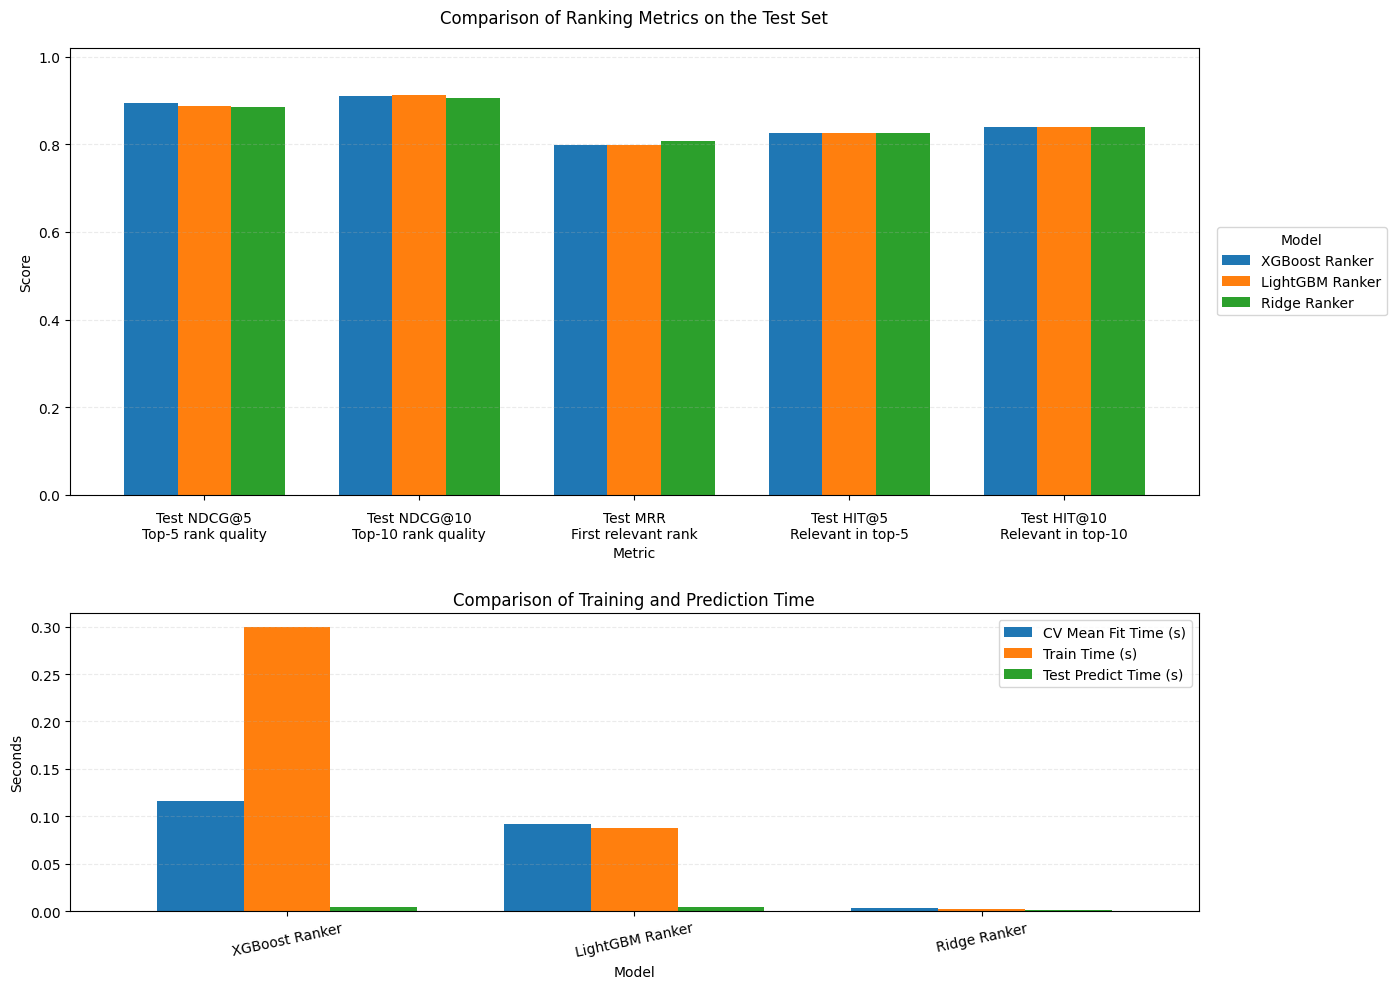

In [38]:
metric_cols = ["Test NDCG@5", "Test NDCG@10", "Test MRR", "Test HIT@5", "Test HIT@10"]
timing_cols = ["CV Mean Fit Time (s)", "Train Time (s)", "Test Predict Time (s)"]
metric_label_map = {
    "Test NDCG@5": "Test NDCG@5\nTop-5 rank quality",
    "Test NDCG@10": "Test NDCG@10\nTop-10 rank quality",
    "Test MRR": "Test MRR\nFirst relevant rank",
    "Test HIT@5": "Test HIT@5\nRelevant in top-5",
    "Test HIT@10": "Test HIT@10\nRelevant in top-10",
}

fig, axes = plt.subplots(2, 1, figsize=(16, 10), gridspec_kw={"height_ratios": [3, 2]})
comparison_summary_df.set_index("Model")[metric_cols].T.plot(kind="bar", ax=axes[0], width=0.75)
axes[0].set_title("Comparison of Ranking Metrics on the Test Set", pad=18)
axes[0].set_xlabel("Metric")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.02)
axes[0].set_xticklabels([metric_label_map[col] for col in metric_cols], rotation=0)
axes[0].tick_params(axis="x", pad=8)
axes[0].grid(axis="y", linestyle="--", alpha=0.25)
axes[0].legend(title="Model", loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=True)

comparison_summary_df.set_index("Model")[timing_cols].plot(kind="bar", ax=axes[1], width=0.75)
axes[1].set_title("Comparison of Training and Prediction Time")
axes[1].set_ylabel("Seconds")
axes[1].tick_params(axis="x", rotation=12)
axes[1].grid(axis="y", linestyle="--", alpha=0.25)

plt.tight_layout(rect=(0, 0, 0.88, 1), h_pad=2.2)
plt.show()


The three models achieve very similar ranking performance, with all of them reaching high `NDCG@5` and `NDCG@10` scores. Among them, **Ridge Ranker** is slightly ahead on most test ranking metrics, while **XGBoost Ranker** is very close behind. **LightGBM Ranker** performs only slightly lower, which suggests that the handcrafted features already capture a large part of the ranking signal.

From the efficiency perspective, **Ridge Ranker** is by far the cheapest model to train and predict. **LightGBM Ranker** offers a strong balance between effectiveness and speed, while **XGBoost Ranker** is the most computationally expensive without providing a clearly dominant improvement in ranking quality.


### Comparing Features Across the Three Models

In this notebook, the term `signal` is used as a general name for the strength of each feature's effect.
- for LightGBM and XGBoost, `signal` refers to `feature importance`
- for Ridge, `signal` refers to the magnitude of the `coefficient`

To place all three models on the same chart, the values are converted to absolute values and then normalized into `signal_norm`.

Therefore, this chart should be interpreted as a **relative comparison of feature influence**, not as a direct comparison of the original units used by the three models.


Model,LightGBM Ranker,Ridge Ranker,XGBoost Ranker
feature_label,,,
Price suitability,0.000000,0.019158,0.000000
Service match (delivery / table booking),0.116429,0.094554,0.047241
Average rating score,0.231429,0.084578,0.048027
Overall popularity score,0.290714,0.006623,0.031274
Match between the query and the restaurant description,0.304286,0.330427,0.046515
Location / district match,0.057143,0.464661,0.826943


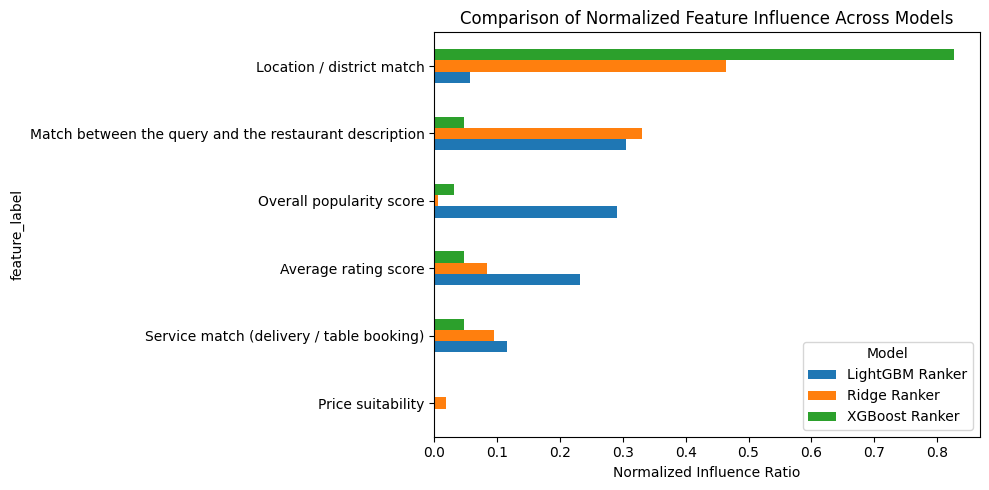

In [36]:
signal_compare_df = pd.concat([run["signal_df"] for run in model_runs.values()], ignore_index=True)
signal_compare_df["feature_label"] = signal_compare_df["feature"].map(FEATURE_LABELS)
signal_pivot_df = (
    signal_compare_df
    .pivot(index="feature_label", columns="Model", values="signal_norm")
    .fillna(0.0)
)
signal_pivot_df = signal_pivot_df.loc[signal_pivot_df.max(axis=1).sort_values(ascending=True).index]
display(signal_pivot_df)

plt.figure(figsize=(10, 5))
signal_pivot_df.plot(kind="barh", ax=plt.gca())
plt.title("Comparison of Normalized Feature Influence Across Models")
plt.xlabel("Normalized Influence Ratio")
plt.tight_layout()
plt.show()


The chart shows that the three models do not rely on the features in the same way, even though they are trained on the same feature set.

The most striking result is that **XGBoost Ranker** depends heavily on **location / district match**, suggesting that location acts as the strongest decision rule in that model. In contrast, **LightGBM Ranker** gives much more weight to **text-based relevance**, **overall popularity**, and **average rating**, indicating a more balanced use of multiple signals.

**Ridge Ranker** appears to distribute its importance more smoothly across a few main features, especially **location match** and **text match**, which is consistent with a linear model that combines signals additively rather than through complex tree splits.

Another important observation is that **price suitability** has very little influence across all three models. This suggests that, in the current dataset and feature design, price is a weaker ranking signal than text relevance, location, or popularity.

Overall, the chart suggests:
- **Location** is the dominant feature for XGBoost
- **Text relevance** plays a strong role in both LightGBM and Ridge
- **Popularity** and **average rating** matter more in LightGBM than in the other models
- **Price** contributes the least in the current setup


---

## Conclusion

Although LightGBM and XGBoost achieve slightly higher ranking metrics, the improvement over Ridge is relatively small. At the same time, **Ridge Ranker** is clearly the fastest and simplest model among the three.

This makes Ridge the most practical choice in this project for several reasons:
- it delivers competitive performance with only a small gap in accuracy
- it has the lowest training and prediction cost
- it is easier to interpret because each feature has a direct linear coefficient
- it is more suitable for explaining model behavior in an academic or reporting setting

Given the current feature set, Ridge already captures most of the useful ranking signal. Therefore, it offers the best balance between **performance, efficiency, and interpretability**, making it the most appropriate final model for this task.
